In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")



In [2]:
df = pd.read_csv("crime.csv")
df

,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4
5,6,Goa,3393,2099,2711,15.7,172.8,75.9
6,7,Gujarat,381849,273056,134600,709.3,189.8,89.8
7,8,Haryana,103276,112720,125435,299.7,418.6,43.3
8,9,Himachal Pradesh,14803,13041,13231,74.4,177.8,82.9
9,10,Jharkhand,51033,47684,48726,391.4,124.5,58.2


In [3]:
df.head()

,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 8 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Sl. No.                                          39 non-null     object 
 1   State/UT                                         39 non-null     object 
 2   2020                                             39 non-null     int64  
 3   2021                                             39 non-null     int64  
 4   2022                                             39 non-null     int64  
 5   Mid-Year Projected Population (in Lakhs) (2022)  39 non-null     float64
 6   Rate of Cognizable Crimes (IPC) (2022)           39 non-null     float64
 7   Chargesheeting Rate (2022)                       39 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 2.6+ KB


In [5]:
df.shape

(39, 8)

In [6]:
df.isnull().sum()

Sl. No.                                            0
State/UT                                           0
2020                                               0
2021                                               0
2022                                               0
Mid-Year Projected Population (in Lakhs) (2022)    0
Rate of Cognizable Crimes (IPC) (2022)             0
Chargesheeting Rate (2022)                         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns="Sl. No.")

In [9]:
df.head(3)

,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,Assam,111558,119883,59315,354.9,167.1,32.6


In [10]:
df.shape

(39, 7)

In [11]:
df.columns = df.columns.str.strip()

In [12]:
df = df.rename(columns={
    "State/UT":"State",
    "2020":"Crime_2020",
    "2021":"Crime_2021",
    "2022":"Crime_2022"
})

In [13]:
df.columns

Index(['State', 'Crime_2020', 'Crime_2021', 'Crime_2022',
       'Mid-Year Projected Population (in Lakhs) (2022)',
       'Rate of Cognizable Crimes (IPC) (2022)', 'Chargesheeting Rate (2022)'],
      dtype='object')

In [14]:
df.head()

,State,Crime_2020,Crime_2021,Crime_2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,Assam,111558,119883,59315,354.9,167.1,32.6
3,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [15]:
#drop aggregeate rows
df = df[~df["State"].isin(["Total State (S)","Total UT(S)", "Total ALL India"])]
df.reset_index(drop = True , inplace = True)


In [16]:
df.shape

(37, 7)

In [17]:
df = df.rename(columns={
    "Mid-Year Projected Population (in Lakhs) (2022)":"Population_2022",
    "Rate of Cognizable Crimes (IPC) (2022)":"Crime_rate_2022",
    "Chargesheeting Rate (2022)":"Chargesetting_Rate"
    
})

In [18]:
df.columns

Index(['State', 'Crime_2020', 'Crime_2021', 'Crime_2022', 'Population_2022',
       'Crime_rate_2022', 'Chargesetting_Rate'],
      dtype='object')

In [19]:
df.describe()

,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesetting_Rate
count,3.700000e+01,3.700000e+01,3.700000e+01,37.000000,37.000000,37.000000
mean,2.299652e+05,1.980195e+05,1.925070e+05,745.808108,241.708108,68.081081
std,7.020045e+05,5.970972e+05,5.808242e+05,2259.165040,232.245479,20.057332
min,1.070000e+02,8.900000e+01,6.400000e+01,0.700000,45.400000,10.400000
25%,2.583000e+03,2.484000e+03,2.941000e+03,16.200000,142.900000,58.000000
50%,5.103300e+04,4.768400e+04,4.872600e+04,299.500000,177.800000,75.300000
75%,1.889970e+05,1.796110e+05,1.585470e+05,674.100000,291.600000,82.400000
max,4.254356e+06,3.663360e+06,3.561379e+06,13797.500000,1424.100000,96.000000


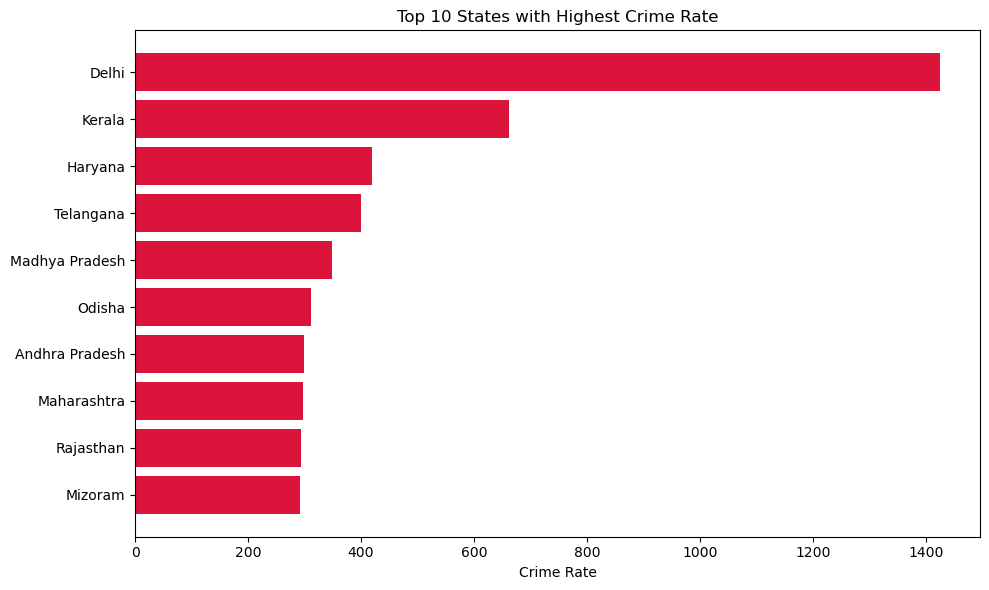

In [20]:
#top 10 states high crime rate
top10 = df.nlargest(10 , "Crime_rate_2022")[["State" , "Crime_rate_2022"]]
plt.figure(figsize=(10,6))
plt.barh(top10['State'] , top10["Crime_rate_2022"] , color = "crimson")
plt.xlabel("Crime Rate")
plt.title("Top 10 States with Highest Crime Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
#Crime trend 2020  2022
# total crime per year -----------------
years = ['Crime_2020' , 'Crime_2021' , 'Crime_2022']
total = df[years].sum()
total

Crime_2020    8508712
Crime_2021    7326720
Crime_2022    7122758
dtype: int64

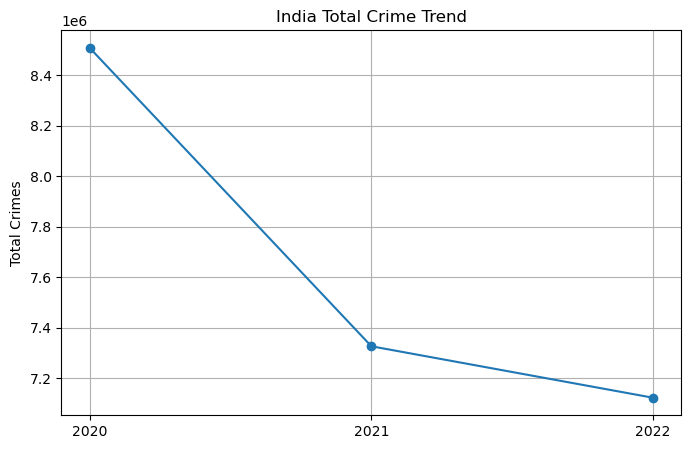

In [22]:
plt.figure(figsize=(8,5))
plt.plot(['2020','2021','2022'] , total.values , marker = "o")
plt.title("India Total Crime Trend")
plt.ylabel("Total Crimes")
plt.grid(True)
plt.show()

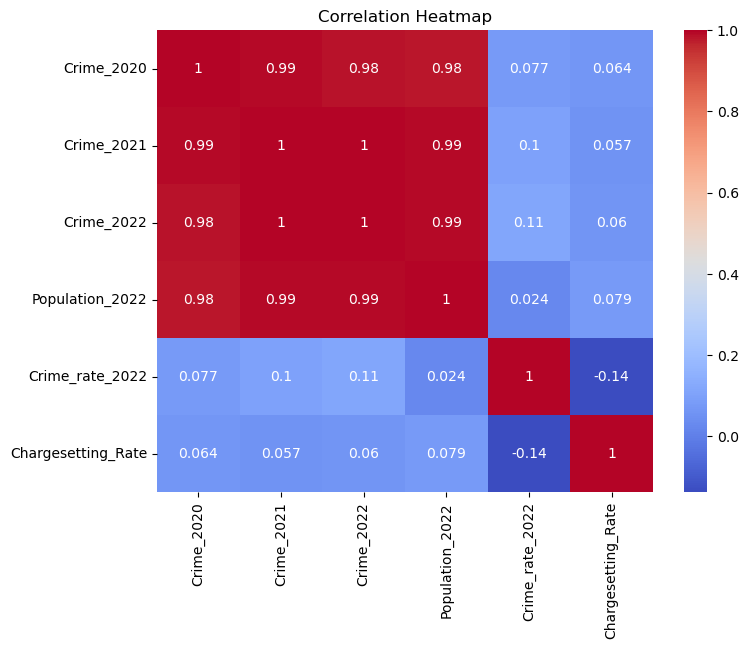

In [23]:
#correlation heatmap 
plt.figure(figsize  = (8,6))
sns.heatmap(df.drop(columns = "State").corr() , annot = True , cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**FEATURE ENGENERRING**

In [24]:
#how much crime increses or decreses from 2020 to 2021
df['Crime_change_20_21'] = df["Crime_2021"] - df["Crime_2020"]
#how much crime increses or decreses from 2021 to 2022
df['Crime_change_21_22'] = df["Crime_2022"] - df["Crime_2021"]
#percentage change from 2020 to 2022 
df['Crime_change_pct'] = ((df["Crime_2022"] - df["Crime_2020"]) / df["Crime_2020"]) *100
# print(df[["State" , 'Crime_change_20_21' , 'Crime_change_21_22' , 'Crime_change_pct']]) 
df

,State,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesetting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050
2,Assam,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348
3,Bihar,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148
5,Goa,3393,2099,2711,15.7,172.8,75.9,-1294,612,-20.100206
6,Gujarat,381849,273056,134600,709.3,189.8,89.8,-108793,-138456,-64.750464
7,Haryana,103276,112720,125435,299.7,418.6,43.3,9444,12715,21.456098
8,Himachal Pradesh,14803,13041,13231,74.4,177.8,82.9,-1762,190,-10.619469
9,Jharkhand,51033,47684,48726,391.4,124.5,58.2,-3349,1042,-4.520604


In [25]:
#features based on population :- 
#crime per lakh population is 
df['Crime_per_lakh_2022'] = df['Crime_2022'] / df['Population_2022']
df['Crime_Average'] = (df['Crime_2020'] + df['Crime_2021'] + df['Crime_2022']) / 3

In [26]:
df

,State,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesetting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct,Crime_per_lakh_2022,Crime_Average
0,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367,298.976051,1.757183e+05
1,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050,148.903226,2.392667e+03
2,Assam,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348,167.131586,9.691867e+04
3,Bihar,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543,168.150243,1.972610e+05
4,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148,246.484140,6.985233e+04
5,Goa,3393,2099,2711,15.7,172.8,75.9,-1294,612,-20.100206,172.675159,2.734333e+03
6,Gujarat,381849,273056,134600,709.3,189.8,89.8,-108793,-138456,-64.750464,189.764557,2.631683e+05
7,Haryana,103276,112720,125435,299.7,418.6,43.3,9444,12715,21.456098,418.535202,1.138103e+05
8,Himachal Pradesh,14803,13041,13231,74.4,177.8,82.9,-1762,190,-10.619469,177.836022,1.369167e+04
9,Jharkhand,51033,47684,48726,391.4,124.5,58.2,-3349,1042,-4.520604,124.491569,4.914767e+04


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                37 non-null     object 
 1   Crime_2020           37 non-null     int64  
 2   Crime_2021           37 non-null     int64  
 3   Crime_2022           37 non-null     int64  
 4   Population_2022      37 non-null     float64
 5   Crime_rate_2022      37 non-null     float64
 6   Chargesetting_Rate   37 non-null     float64
 7   Crime_change_20_21   37 non-null     int64  
 8   Crime_change_21_22   37 non-null     int64  
 9   Crime_change_pct     37 non-null     float64
 10  Crime_per_lakh_2022  37 non-null     float64
 11  Crime_Average        37 non-null     float64
dtypes: float64(6), int64(5), object(1)
memory usage: 3.6+ KB


In [28]:
#drop state 
df = df.drop(columns = "State")

In [29]:
df = df.drop(columns="Crime_per_lakh_2022")
df.shape

(37, 10)

In [30]:
df.head(2)

,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesetting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct,Crime_Average
0,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367,175718.333333
1,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050,2392.666667


In [31]:
df

,Crime_2020,Crime_2021,Crime_2022,Population_2022,Crime_rate_2022,Chargesetting_Rate,Crime_change_20_21,Crime_change_21_22,Crime_change_pct,Crime_Average
0,188997,179611,158547,530.3,299.0,86.5,-9386,-21064,-16.111367,1.757183e+05
1,2244,2626,2308,15.5,148.8,47.2,382,-318,2.852050,2.392667e+03
2,111558,119883,59315,354.9,167.1,32.6,8325,-60568,-46.830348,9.691867e+04
3,194698,186006,211079,1255.3,168.1,75.4,-8692,25073,8.413543,1.972610e+05
4,65216,70519,73822,299.5,246.5,80.4,5303,3303,13.196148,6.985233e+04
5,3393,2099,2711,15.7,172.8,75.9,-1294,612,-20.100206,2.734333e+03
6,381849,273056,134600,709.3,189.8,89.8,-108793,-138456,-64.750464,2.631683e+05
7,103276,112720,125435,299.7,418.6,43.3,9444,12715,21.456098,1.138103e+05
8,14803,13041,13231,74.4,177.8,82.9,-1762,190,-10.619469,1.369167e+04
9,51033,47684,48726,391.4,124.5,58.2,-3349,1042,-4.520604,4.914767e+04


**Start making model**

In [32]:
# x = df.drop(columns=["Crime_rate_2022"])
# y = df["Crime_rate_2022"]

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_absolute_error

In [34]:
# x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.20 , random_state = 42)

In [35]:
from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# x_train_scaled = scaler.fit_transform(x_train)
# x_test_scaled = scaler.transform(x_test)

In [36]:
# model = LinearRegression()
# model.fit(x_train_scaled , y_train)

In [37]:
# y_pred = model.predict(x_test_scaled)

In [38]:
# r2 = r2_score(y_test , y_pred)
# r2

In [39]:
# mae = mean_absolute_error(y_test , y_pred)

In [40]:
# mae

trying random forest

In [41]:
from sklearn.ensemble import RandomForestRegressor
# rf_model  = RandomForestRegressor(n_estimators=100 , random_state=42)
# rf_model.fit(x_train , y_train)

In [42]:
# y_pred_rf = rf_model.predict(x_test)

In [43]:
# r2_rf = r2_score(y_test , y_pred_rf)

In [44]:
# r2_rf

In [45]:
# mae = mean_absolute_error(y_test , y_pred_rf)

In [46]:
# mae

r2 is in negative so check outliers

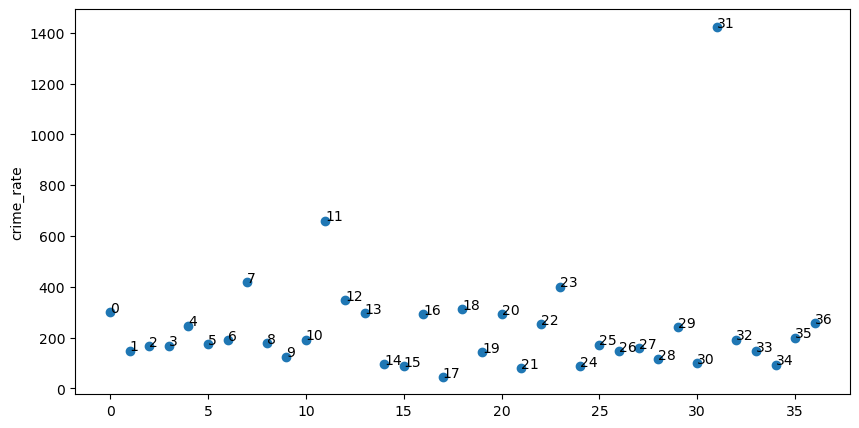

In [91]:
plt.figure(figsize=(10,5))
plt.scatter(df.index , df['Crime_rate_2022'])
for i , row in df.iterrows():
    plt.annotate(row['State'] if "State" in df.columns
                 else str(i),
                 (i , row["Crime_rate_2022"])) 
plt.ylabel("crime_rate")
plt.show()

In [92]:
from sklearn.model_selection import cross_val_score
# rf_model1 = RandomForestRegressor(n_estimators=100 , random_state=42)
# cv_scores = cross_val_score(rf_model1 , x, y , cv=5 , scoring='r2')
# # print(f"CV R2 Scores:{cv_scores}")
# print(f"Mean r2:{cv_scores.mean():.2f}")

In [93]:
# Delhi, Kerala outlier remove 
# df_clean = df[df['Crime_rate_2022'] < 500]

# print(f"Rows after removing outliers: {df_clean.shape[0]}")

# x_clean = df_clean.drop(columns=['Crime_rate_2022'])
# y_clean = df_clean['Crime_rate_2022']

# # Cross Validation
# rf_model2 = RandomForestRegressor(n_estimators=100, random_state=42)
# cv_scores_clean = cross_val_score(rf_model2, x_clean, y_clean, 
#                                    cv=5, scoring='r2')

# print(f"CV R2 Scores: {cv_scores_clean}")
# print(f"Mean R2: {cv_scores_clean.mean():.2f}")

In [94]:
#split on clean data 
# x_train_c , x_test_c , y_train_c , y_test_c = train_test_split(x_clean , y_clean , test_size=0.20 , random_state=42)
# rf_final = RandomForestRegressor(n_estimators=100 , random_state=42)
# rf_final.fit(x_train_c , y_train_c)

In [95]:
# y_pred_final = rf_final.predict(x_test_c)
# r2_score_final = r2_score(y_test_c , y_pred_final)
# r2_score_final

In [96]:
# mae_final = mean_absolute_error(y_test_c , y_pred_final)

In [97]:
# mae_final

In [98]:
# since dataset is small 36 rows beacuse of this the predictive power of model is limited so with more data more results are possible 
# so i am going to predict now crime_2022 beacuse it has good correlation insted of crime_rate_2022
# so i am commenting the code from x and y from above to this point so that we can focus on new target

In [99]:
x = df[["Crime_2020" , "Crime_2021" , "Population_2022" , "Crime_change_20_21"]]
y = df["Crime_2022"]

In [100]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.10 , random_state= 42)

In [101]:
rf_model = RandomForestRegressor()
rf_model.fit(x_train , y_train)

RandomForestRegressor()

In [102]:
y_pred = rf_model.predict(x_test)

In [103]:
r_two = r2_score(y_test , y_pred)

In [104]:
r_two

0.9111438261243594

In [105]:
cv_scores = cross_val_score(rf_model , x , y , cv = 5 , scoring="r2" )
cv_scores

array([ 0.29273467,  0.87043826, -8.3537325 ,  0.88875047,  0.03210717])

In [106]:
cv_scores.mean()

np.float64(-1.253940386195302)

In [107]:
#remove dehli,kerla outlier and clean again as above where we removed the outlier of dehli is now commented

In [108]:
df_clean = df[df['Crime_rate_2022'] < 500]
x_clean = df[["Crime_2020" , "Crime_2021" , "Population_2022" , "Crime_change_20_21"]]
y_clean = df["Crime_2022"]

In [109]:
x_train_c2 , x_test_c2 , y_train_c2 , y_test_c2 = train_test_split(x_clean , y_clean , test_size=0.10 , random_state= 42)

In [110]:
rf_model_clean = RandomForestRegressor()
rf_model_clean.fit(x_train_c2 , y_train_c2)

RandomForestRegressor()

In [111]:
y_pred_clean = rf_model_clean.predict(x_test_c2)

In [112]:
r_two_clean = r2_score(y_test_c2 , y_pred_clean)

In [113]:
r_two_clean

0.9237761012009958

In [114]:
cv_scores_clean = cross_val_score(rf_model , x_clean , y_clean , cv = 5 , scoring="r2" )
cv_scores_clean

array([ 0.34861914,  0.84958328, -5.26971893,  0.90781618,  0.03072033])

In [115]:
cv_scores_clean.mean()

np.float64(-0.6265960019317579)